# Problema 10.3(iii): truncamiento a cuatro modos

En este inciso repetimos la comparación entre el modelo de Galerkin y la ecuación completa, pero conservando ahora cuatro amplitudes:
$$
u(x,t)\approx\sum_{n=1}^{4}a_n(t)\sin(nx).
$$

La condición inicial continúa siendo
$$
u(0,x)=-\sin(x),
$$
por lo que
$$
(a_1(0),a_2(0),a_3(0),a_4(0))=(-1,0,0,0).
$$

## Parámetros utilizados

El enunciado escrito pide estudiar
$$
\frac{1}{k}=\frac{L}{2\pi}=2.5.
$$
En la pizarra de clase se recomendó también el conjunto
$$
\frac{1}{k}=1.94,
\qquad
t_f=20,
\qquad
N_x=32.
$$

Para no reemplazar una indicación por la otra, usamos `2.5` como resultado principal y reproducimos el caso de la pizarra como control numérico. En ambos casos integramos hasta `t_f=20`, porque este tiempo permite observar el comportamiento asintótico con claridad.


## Sistema modal de cuatro amplitudes

Partimos de la ecuación modal general
$$
\dot a_\ell
=(1-k^2\ell^2)\ell^2a_\ell
-\frac{1}{2}\sum_{m=1}^{\infty}m a_m
\left[\operatorname{sg}(\ell-m)a_{|\ell-m|}+a_{\ell+m}\right].
$$
Al truncar en cuatro modos imponemos
$$
a_j=0
\qquad\text{para}\qquad
j>4.
$$
Evaluando la suma para cada valor de `ell`, obtenemos
$$
\boxed{
\begin{aligned}
\dot a_1={}&(1-k^2)a_1
+\frac{1}{2}\left(a_1a_2+a_2a_3+a_3a_4\right),\\
\dot a_2={}&4(1-4k^2)a_2
-\frac{1}{2}a_1^2+a_1a_3+a_2a_4,\\
\dot a_3={}&9(1-9k^2)a_3
-\frac{3}{2}a_1a_2+\frac{3}{2}a_1a_4,\\
\dot a_4={}&16(1-16k^2)a_4
-2a_1a_3-a_2^2.
\end{aligned}}
$$

Los modos adicionales permiten representar transferencias de amplitud que el modelo de dos modos descartaba. En particular, `a_3` es generado por el producto `a_1a_2`, mientras que `a_4` recibe contribuciones de `a_1a_3` y `a_2^2`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})


In [2]:
def rhs_cuatro_modos(a, inverso_k):
    a1, a2, a3, a4 = a
    k = 1.0/inverso_k
    return np.array([
        (1.0-k**2)*a1 + 0.5*(a1*a2 + a2*a3 + a3*a4),
        4.0*(1.0-4.0*k**2)*a2 - 0.5*a1**2 + a1*a3 + a2*a4,
        9.0*(1.0-9.0*k**2)*a3 - 1.5*a1*a2 + 1.5*a1*a4,
        16.0*(1.0-16.0*k**2)*a4 - 2.0*a1*a3 - a2**2,
    ])


def integrar_modal_4(inverso_k, tf=20.0, dt=1e-3,
                      a0=(-1.0, 0.0, 0.0, 0.0)):
    n_steps = int(np.ceil(tf/dt))
    dt = tf/n_steps
    t = np.linspace(0.0, tf, n_steps + 1)
    a = np.empty((n_steps + 1, 4))
    a[0] = a0

    for n in range(n_steps):
        an = a[n]
        k1 = rhs_cuatro_modos(an, inverso_k)
        k2 = rhs_cuatro_modos(an + 0.5*dt*k1, inverso_k)
        k3 = rhs_cuatro_modos(an + 0.5*dt*k2, inverso_k)
        k4 = rhs_cuatro_modos(an + dt*k3, inverso_k)
        a[n + 1] = an + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0

    return t, a


## Solución pseudoespectral de referencia

Para la PDE completa reutilizamos el método del inciso anterior:

- FFT en una grilla periódica.
- Regla de los dos tercios para eliminar aliasing.
- RK2 explícito de Heun para avanzar toda la ecuación en el tiempo.
- Extracción de las cuatro primeras amplitudes mediante
$$
a_n(t)=-\frac{2}{N_x}\operatorname{Im}\left(\widehat u_n(t)\right).
$$

Usamos `N_x=32` en ambos casos, siguiendo la resolución recomendada en la pizarra.

En los gráficos se indican ahora las dos partes de cada método:
$$
\text{Galerkin de cuatro modos}+\text{RK4 clásico},
$$
$$
\text{PDE pseudoespectral}+\text{RK2 de Heun}.
$$
Galerkin y pseudoespectral determinan cómo se aproxima la dependencia espacial. RK4 y RK2 determinan cómo se avanza en el tiempo. RK4 utiliza cuatro pendientes y es de orden cuatro; Heun utiliza dos pendientes y es de orden dos. Esta segunda combinación es la que aparece en el apunte de la materia.


In [3]:
def paso_rk2_heun(X, dX_dt, dt):
    """RK2 de Heun, siguiendo la implementación del apunte."""
    k1 = dX_dt(X)
    k2 = dX_dt(X + dt*k1)
    return X + 0.5*dt*(k1 + k2)


def integrar_pseudoespectral(inverso_k, Nx=32, tf=20.0, dt=5e-4):
    k = 1.0/inverso_k
    x = 2.0*np.pi*np.arange(Nx)/Nx
    modos = np.fft.fftfreq(Nx, d=1.0/Nx)
    lineal = modos**2-k**2*modos**4
    mascara = np.abs(modos) <= Nx/3.0
    n_steps = int(np.ceil(tf/dt))
    dt = tf/n_steps
    t = np.linspace(0.0, tf, n_steps + 1)
    def derivada_temporal(v):
        u = np.fft.ifft(v).real
        producto = np.fft.fft(u*u)
        producto[~mascara] = 0.0
        return lineal*v - 0.5j*modos*producto

    v = np.fft.fft(-np.sin(x))
    historia = np.empty((n_steps + 1, Nx), dtype=np.complex128)
    historia[0] = v
    for n in range(n_steps):
        v = paso_rk2_heun(v, derivada_temporal, dt)
        v[~mascara] = 0.0
        v[0] = 0.0
        historia[n + 1] = v

    u = np.fft.ifft(historia, axis=1).real
    return t, x, u, historia


def extraer_amplitudes(historia_fft, cantidad=4):
    Nx = historia_fft.shape[1]
    return -2.0*historia_fft[:, 1:cantidad + 1].imag/Nx


In [4]:
casos = {
    "enunciado": {"inverso_k": 2.5, "Nx": 32},
    "pizarra": {"inverso_k": 1.94, "Nx": 32},
}
resultados = {}

for nombre, parametros in casos.items():
    inverso_k = parametros["inverso_k"]
    Nx = parametros["Nx"]
    t, x, u, historia = integrar_pseudoespectral(inverso_k, Nx=Nx)
    amplitudes = extraer_amplitudes(historia, 4)
    tm, modal = integrar_modal_4(inverso_k)
    resultados[nombre] = (t, x, u, amplitudes, tm, modal)

    print(f"{nombre}: 1/k={inverso_k}, Nx={Nx}")
    print("  PDE:    ", np.array2string(amplitudes[-1], precision=8))
    print("  4 modos:", np.array2string(modal[-1], precision=8))


enunciado: 1/k=2.5, Nx=32
  PDE:     [-1.01464878e-17 -6.07580012e+00 -1.54235943e-17 -1.40542608e+00]
  4 modos: [ 2.24009093e-25 -5.99519808e+00 -5.01930494e-25 -1.44000000e+00]
pizarra: 1/k=1.94, Nx=32
  PDE:     [-1.02815708 -1.27193676 -0.15140002 -0.03688729]
  4 modos: [-1.02817582 -1.27151296 -0.15195886 -0.03707986]


## Control de convergencia

Para ambos casos repetimos la PDE con la misma grilla y la mitad del paso temporal:
$$
N_x=32,
\qquad
\Delta t=2.5\times10^{-4}.
$$


In [5]:
_, _, _, historia_fina = integrar_pseudoespectral(
    2.5, Nx=32, tf=20.0, dt=2.5e-4
)
fino_25 = extraer_amplitudes(historia_fina, 4)[-1]
base_25 = resultados["enunciado"][3][-1]
error_25 = np.linalg.norm(fino_25-base_25, ord=np.inf)

_, _, _, historia_fina_pizarra = integrar_pseudoespectral(
    1.94, Nx=32, tf=20.0, dt=2.5e-4
)
fino_194 = extraer_amplitudes(historia_fina_pizarra, 4)[-1]
base_194 = resultados["pizarra"][3][-1]
error_194 = np.linalg.norm(fino_194-base_194, ord=np.inf)

print(f"Error para 1/k=2.5:  {error_25:.3e}")
print(f"Error para 1/k=1.94: {error_194:.3e}")


Error para 1/k=2.5:  2.593e-13
Error para 1/k=1.94: 1.486e-09


## Trayectoria tridimensional

La consigna sugiere representar tres amplitudes. Graficamos el espacio
$$
(a_1,a_2,a_3)
$$
para el modelo de cuatro modos y para la PDE completa. Ambas trayectorias parten de
$$
(-1,0,0)
$$
y evolucionan hacia un estado dominado por los modos pares.


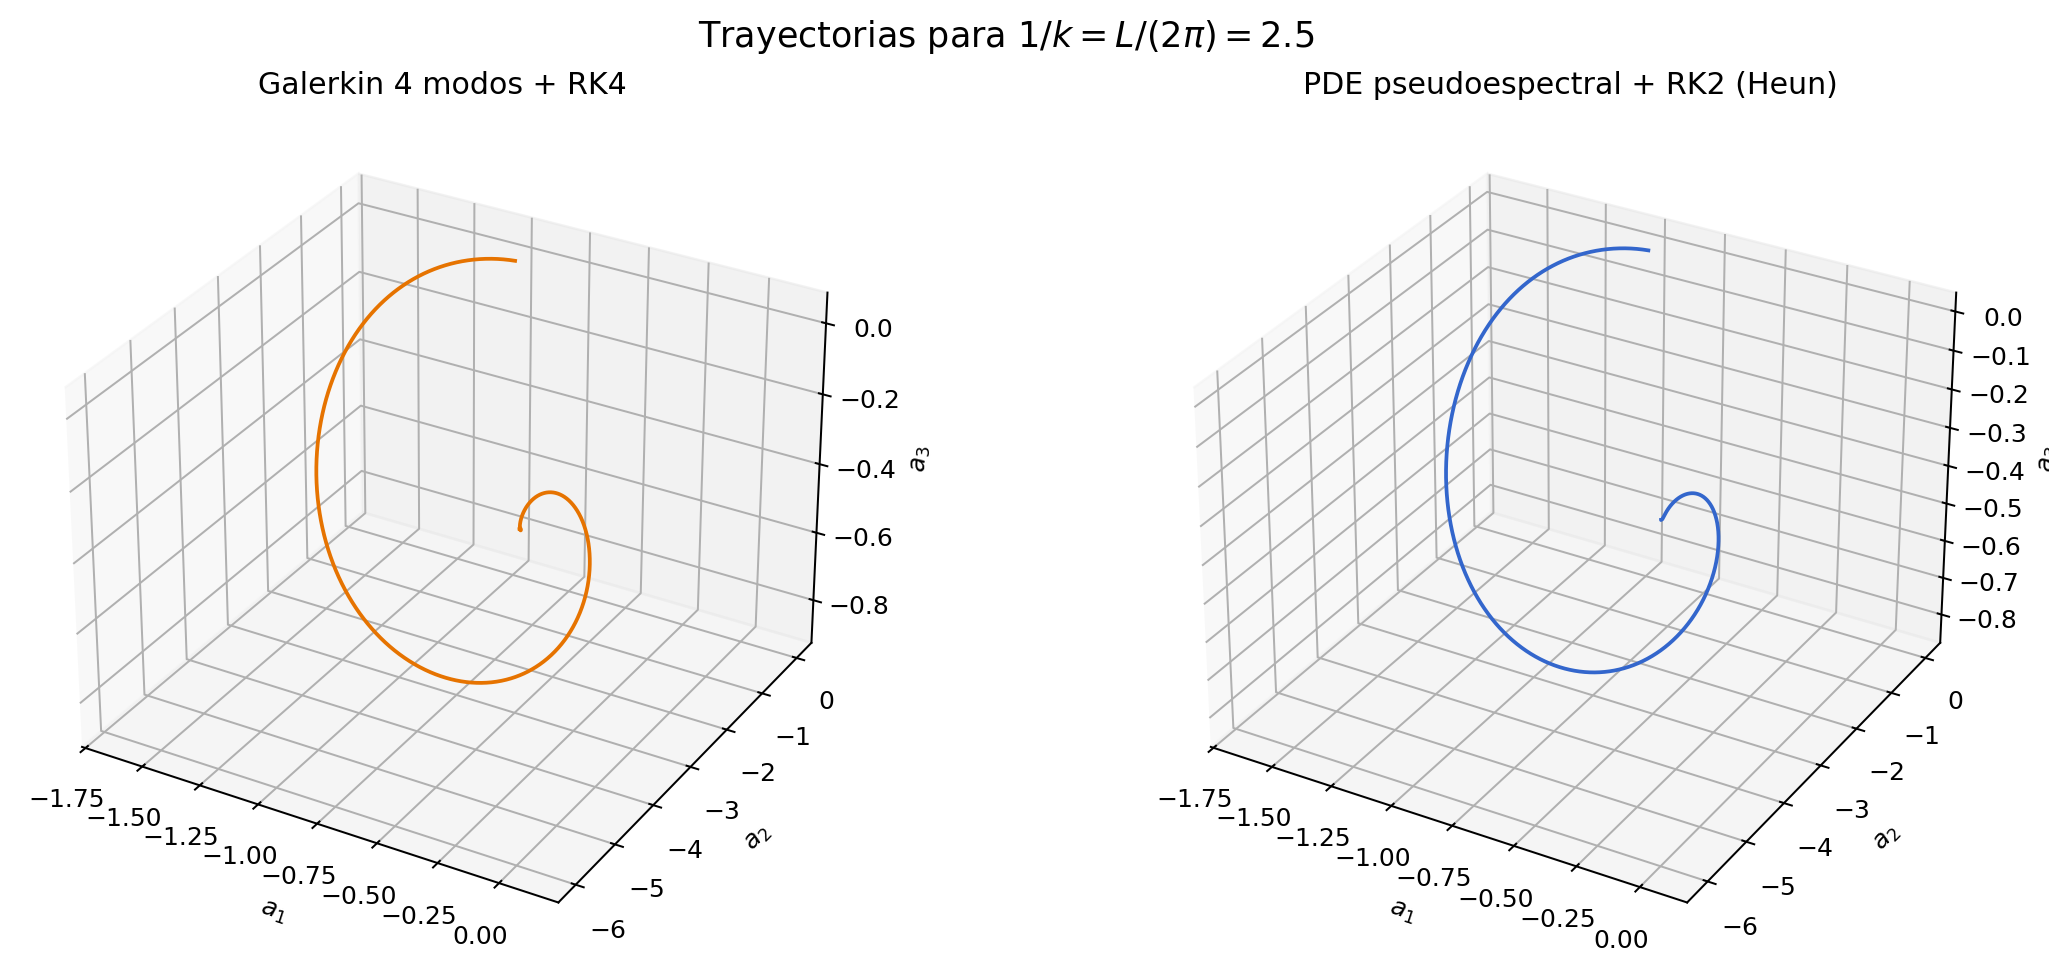

In [6]:
t, _, _, amplitudes, tm, modal = resultados["enunciado"]
fig = plt.figure(figsize=(12.5, 5.3), constrained_layout=True)
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

ax1.plot(modal[:, 0], modal[:, 1], modal[:, 2], color="#E67300", lw=1.5)
ax2.plot(amplitudes[:, 0], amplitudes[:, 1], amplitudes[:, 2],
         color="#3366CC", lw=1.5)

for ax, titulo in ((ax1, "Galerkin 4 modos + RK4"),
                   (ax2, "PDE pseudoespectral + RK2 (Heun)")):
    ax.set_xlabel(r"$a_1$")
    ax.set_ylabel(r"$a_2$")
    ax.set_zlabel(r"$a_3$")
    ax.set_title(titulo)

fig.suptitle(r"Trayectorias para $1/k=L/(2\pi)=2.5$", fontsize=14)
plt.show()


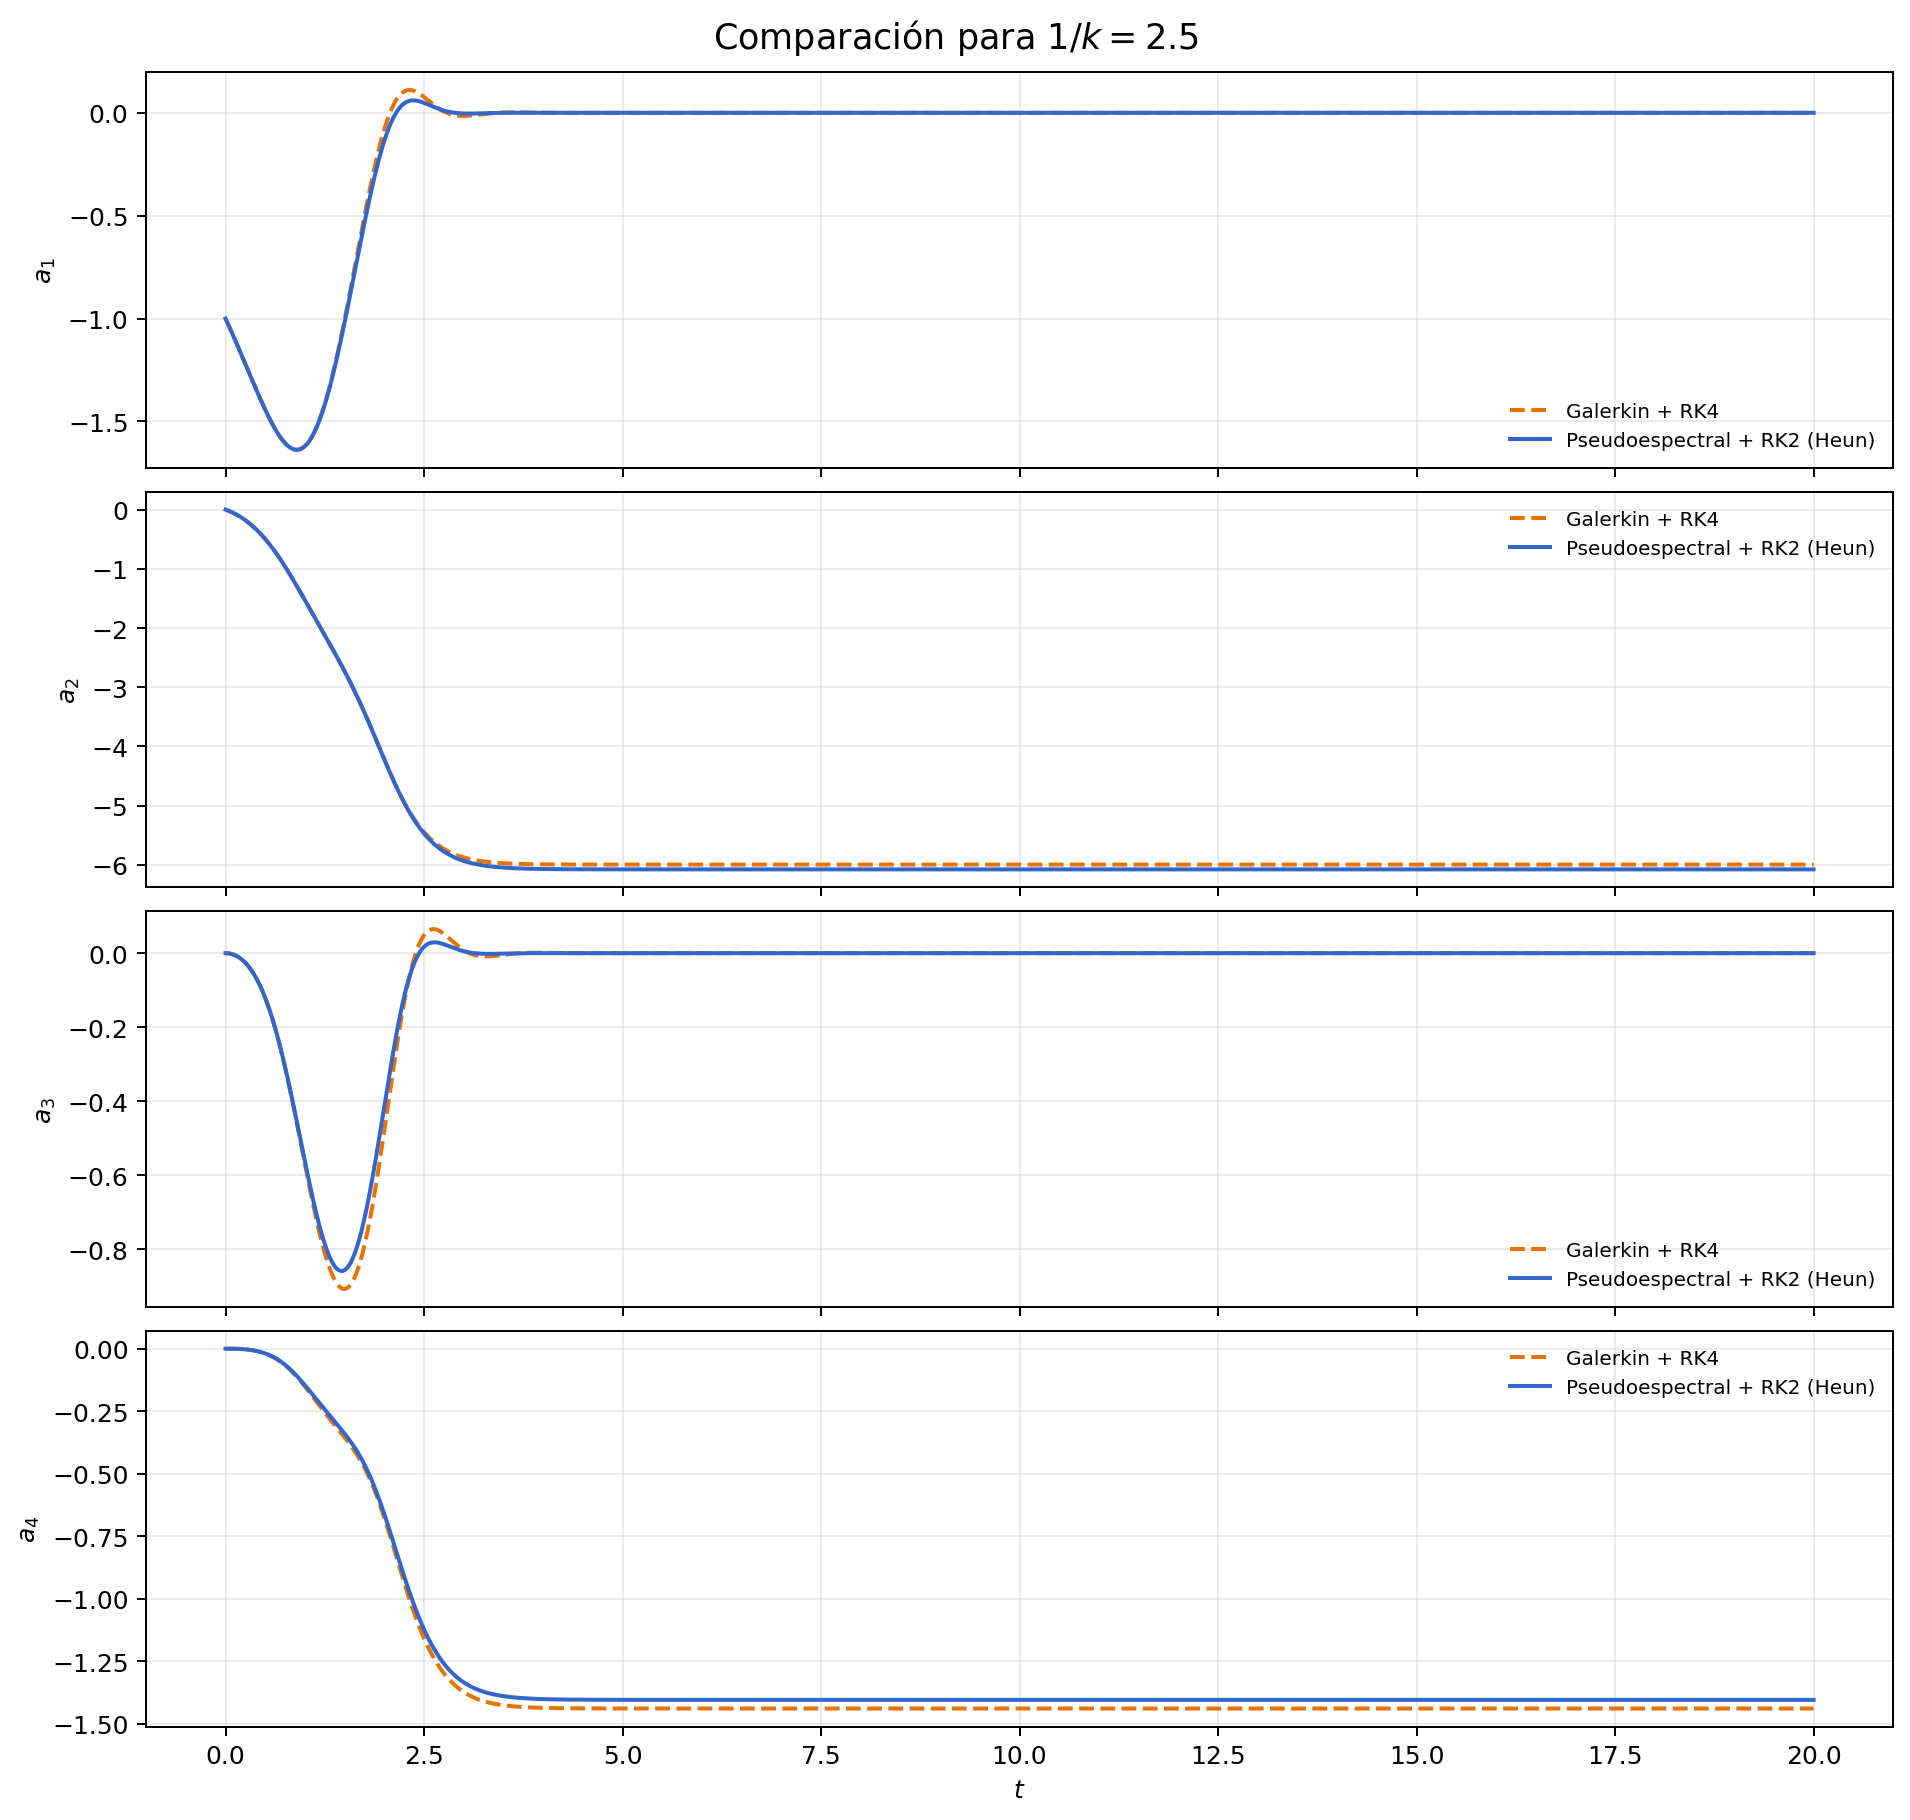

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(10.5, 10.0),
                         sharex=True, constrained_layout=True)

for j, ax in enumerate(axes):
    ax.plot(tm, modal[:, j], "--", color="#E67300", lw=1.6,
            label="Galerkin + RK4")
    ax.plot(t, amplitudes[:, j], color="#3366CC", lw=1.6,
            label="Pseudoespectral + RK2 (Heun)")
    ax.set_ylabel(rf"$a_{j+1}$")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

axes[-1].set_xlabel(r"$t$")
fig.suptitle(r"Comparación para $1/k=2.5$", fontsize=14)
plt.show()


## Control con los parámetros de la pizarra

La recomendación de clase produce una comparación especialmente limpia: las curvas del truncamiento a cuatro modos y de la PDE resultan casi indistinguibles durante todo el intervalo. Esto confirma que `N_x=32` es suficiente para este caso y que cuatro modos capturan la dinámica dominante para
$$
\frac{1}{k}=1.94.
$$


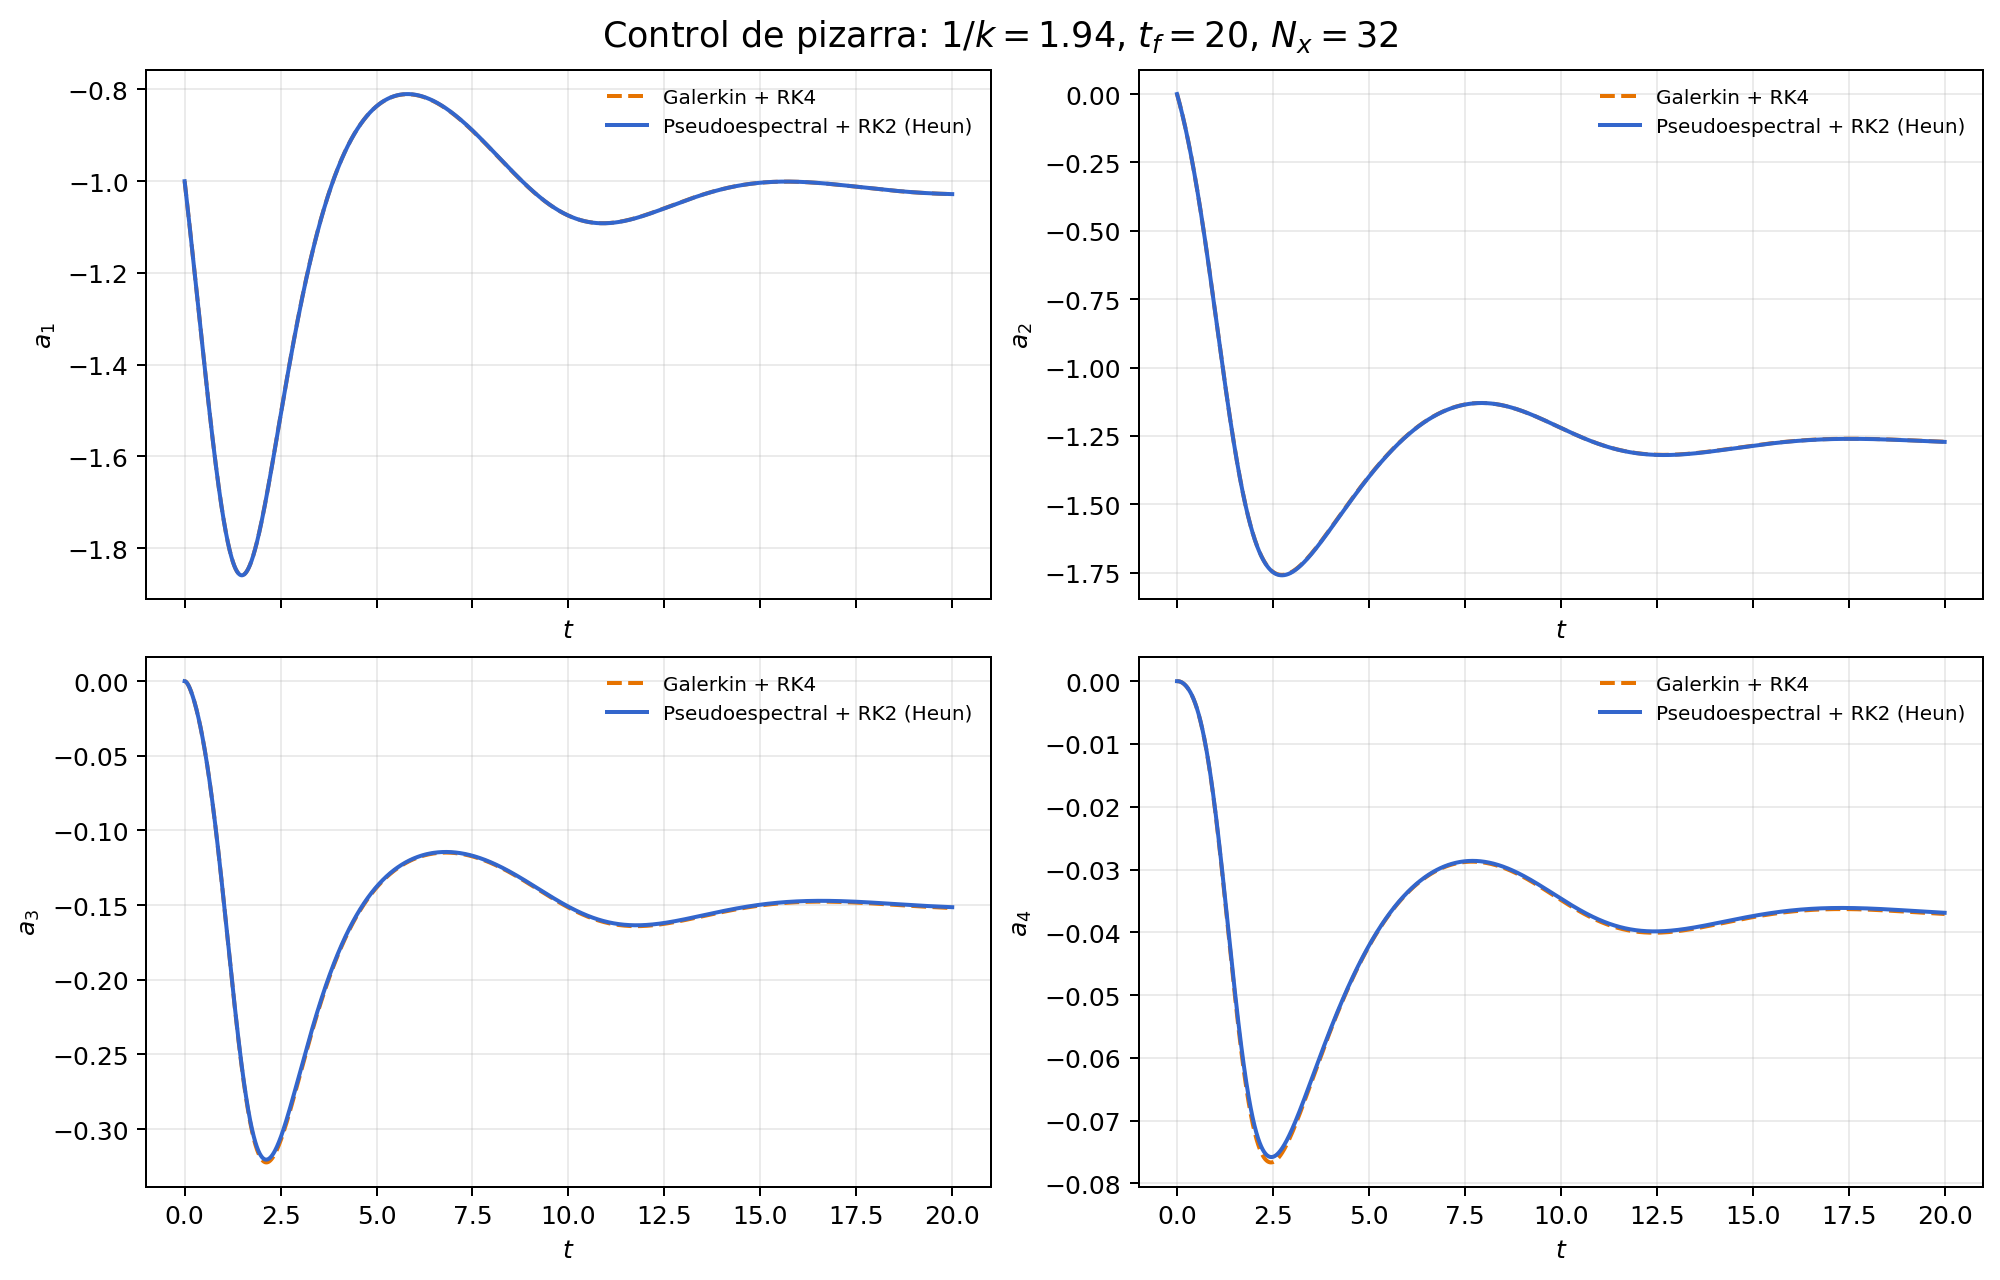

In [8]:
t2, _, _, amp2, tm2, modal2 = resultados["pizarra"]
fig, axes = plt.subplots(2, 2, figsize=(11.0, 7.0),
                         sharex=True, constrained_layout=True)

for j, ax in enumerate(axes.flat):
    ax.plot(tm2, modal2[:, j], "--", color="#E67300", lw=1.6,
            label="Galerkin + RK4")
    ax.plot(t2, amp2[:, j], color="#3366CC", lw=1.6,
            label="Pseudoespectral + RK2 (Heun)")
    ax.set_ylabel(rf"$a_{j+1}$")
    ax.set_xlabel(r"$t$")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle(r"Control de pizarra: $1/k=1.94$, $t_f=20$, $N_x=32$",
             fontsize=14)
plt.show()


## Interpretación

### Caso principal: `1/k = 2.5`

Después de un transitorio breve, tanto la PDE como el modelo de cuatro modos convergen a un estado estacionario dominado por `a_2` y `a_4`. Numéricamente se obtiene aproximadamente
$$
(a_1,a_2,a_3,a_4)_{\mathrm{PDE}}
=(0,-6.0758,0,-1.4054),
$$
mientras que el truncamiento produce
$$
(a_1,a_2,a_3,a_4)_{4\,\mathrm{modos}}
=(0,-5.9952,0,-1.4400).
$$
La coincidencia cualitativa es muy buena, aunque quedan diferencias pequeñas porque la PDE conserva todos los modos superiores.

### Caso de pizarra: `1/k = 1.94`

Las cuatro amplitudes presentan oscilaciones amortiguadas. El modelo reducido y la PDE prácticamente se superponen, mostrando que los primeros cuatro modos contienen casi toda la dinámica relevante en este régimen.

Nuevamente, esta superposición no identifica RK4 con RK2. Indica que ambos integradores temporales están convergidos y que el truncamiento espacial a cuatro modos aproxima muy bien a la solución pseudoespectral.

Los controles de refinamiento dan errores del orden de
$$
3\times10^{-13}
$$
para el caso principal y
$$
2\times10^{-9}
$$
para el caso de la pizarra. Por lo tanto, las diferencias restantes entre Galerkin y la PDE no se deben a una mala elección de grilla o paso temporal, sino al truncamiento modal.
